### Clase 02 — Del Insight a los Datos

###### Análisis descriptivo, diagnóstico y predictivo
###### Ciclo Magistral · Inteligencia de Datos: Análisis e IA Aplicada · 2026
###### Mara Destefanis · Mgter. Ciencia de Datos · Lic. Comunicación Social

### Propósito: predecir TotalVolume semanal por región con LightGBM

→  **Estrategia:** modelo global — todas las regiones en un solo modelo: Ideal un predictivo por región. 


##### Modelo predictivo — Demanda futura de paltas por región


**¿Qué predice este modelo?**
El volumen semanal de paltas vendidas (en libras) por región, usando el historial de ventas y variables de calendario como predictores.

**¿Qué algoritmo usamos y por qué?**
LightGBM (Light Gradient Boosting Machine) — un modelo de árboles de decisión
con boosting por gradiente. Lo elegimos porque:

- **Maneja variables categóricas (región, tipo)** de forma nativa
-  **Captura patrones no lineales y estacionalidad** sin transformaciones complejas
-  **Es rápido, eficiente en memoria y robusto con datasets medianos**
-  **No requiere escalar las variables**

**¿Cómo aprende?**

- El modelo recibe como input features de fecha (año, mes, semana, trimestre)
- el historial reciente de ventas (lags y promedios móviles) y la región/tipo,

y aprende a asociar esas condiciones con el volumen observado.

**Estrategia:**

Un único modelo global entrenado con todas las regiones simultáneamente, usando Region_Geo y Tipo como variables categóricas.

### 0 - Set up 

In [54]:


import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy  as np
from pathlib import Path

# Modelo
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics         import mean_absolute_error, mean_squared_error

# Visualización
import plotly.graph_objects as go
import plotly.express       as px
from plotly.subplots        import make_subplots
import plotly.io            as pio

# ── Paleta y template ─────────────────────────────────────────────────────────
PALETA = {
    "hueso":   "#F2EFE4",
    "oliva":   "#7C8C5E",
    "tierra":  "#A0785A",
    "musgo":   "#4F6347",
    "pizarra": "#5A6472",
    "crema":   "#D9D2C0",
    "ink":     "#2C2C2C",
}

COLORES_SEQ = [
    PALETA["oliva"], PALETA["tierra"],
    PALETA["pizarra"], PALETA["musgo"], PALETA["crema"],
]

TEMPLATE_PALTA = go.layout.Template(
    layout=go.Layout(
        font          = dict(family="Georgia, serif", color=PALETA["ink"], size=12),
        paper_bgcolor = "white",
        plot_bgcolor  = "white",
        title         = dict(font=dict(size=14, color=PALETA["ink"]), x=0.5, xanchor="center"),
        xaxis         = dict(showgrid=False, linecolor=PALETA["ink"], linewidth=0.7),
        yaxis         = dict(gridcolor=PALETA["crema"], gridwidth=0.5,
                             linecolor=PALETA["ink"], linewidth=0.7),
        legend        = dict(bgcolor="rgba(0,0,0,0)", borderwidth=0, font=dict(size=10)),
        colorway      = COLORES_SEQ,
    )
)
pio.templates["palta"] = TEMPLATE_PALTA
pio.templates.default  = "palta"

pd.set_option("display.float_format", "{:,.2f}".format)



In [55]:
# ── Carga ─────────────────────────────────────────────────────────────────────

DATA_PATH = Path(r"C:\Users\ASUS\Documents\Teacher\Clases_Magistrales\sesion2_Delosdatos-al-insight\Datos\palta_1.csv")

palta_1 = pd.read_csv(DATA_PATH, parse_dates=["Fecha"])

print(f"Dataset cargado : {palta_1.shape[0]:,} filas · {palta_1.shape[1]} columnas")
print(f"Período         : {palta_1['Fecha'].min().date()} → {palta_1['Fecha'].max().date()}")
print(f"Regiones        : {palta_1['Region_Geo'].nunique()}")
print("Setup listo — arrancamos con feature engineering.")

Dataset cargado : 52,483 filas · 9 columnas
Período         : 2015-01-04 → 2023-12-03
Regiones        : 15
Setup listo — arrancamos con feature engineering.


In [56]:
# ── Carga de datos ────────────────────────────────────────────────────────────
DATA_PATH = Path(r"C:\Users\ASUS\Documents\Teacher\Clases_Magistrales\sesion2_Delosdatos-al-insight\Datos\palta_1.csv")

palta_1 = pd.read_csv(DATA_PATH, parse_dates=["Fecha"])

print(f"Dataset cargado: {palta_1.shape[0]:,} filas · {palta_1.shape[1]} columnas")
print(f"Dataset cargado : {palta_1.shape[0]:,} filas · {palta_1.shape[1]} columnas")
print(f"Período         : {palta_1['Fecha'].min().date()} → {palta_1['Fecha'].max().date()}")
print(f"Regiones        : {palta_1['Region_Geo'].nunique()}")
print("Setup listo — arrancamos con feature engineering.")


Dataset cargado: 52,483 filas · 9 columnas
Dataset cargado : 52,483 filas · 9 columnas
Período         : 2015-01-04 → 2023-12-03
Regiones        : 15
Setup listo — arrancamos con feature engineering.


In [57]:
display(palta_1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52483 entries, 0 to 52482
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Fecha              52483 non-null  datetime64[ns]
 1   PrecioPromedio     52483 non-null  float64       
 2   TotalVolume        52483 non-null  float64       
 3   Palta_Normal       52483 non-null  float64       
 4   Palta_Grande       52483 non-null  float64       
 5   Palta_Extragrande  52483 non-null  float64       
 6   TotalBags          52483 non-null  float64       
 7   Tipo               52483 non-null  object        
 8   Region_Geo         52483 non-null  object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 3.6+ MB


None

In [58]:
# Formato 
# vamos a trabajar solo con paltas convencionales porque organico se comporta como vimos en el
# análisis descriptivo de otra manera. 

palta_1 = palta_1[palta_1['Tipo'] == 'conventional'].copy() 
palta_1[['Tipo','Region_Geo']] =palta_1[['Tipo','Region_Geo']].astype('category')
palta_1['Fecha'] = pd.to_datetime(palta_1["Fecha"])

### 1 Creando Feature Enginnering
##### # Construimos los predictores a partir de Fecha, Region_Geo y Tipo 

In [59]:

predictivo_1 = palta_1[["Fecha", "Region_Geo", "Tipo", "TotalVolume","PrecioPromedio"]].copy()

# Ordenamos — crítico para que los lags no mezclen el futuro con el pasado
predictivo_1 = predictivo_1.sort_values(["Region_Geo", "Tipo", "Fecha"]).reset_index(drop=True)


# ── Features de calendario ────────────────────────────────────────────────────

predictivo_1["anio"]      = predictivo_1["Fecha"].dt.year
predictivo_1["mes"]       = predictivo_1["Fecha"].dt.month
predictivo_1["semana"]    = predictivo_1["Fecha"].dt.isocalendar().week.astype(int)
predictivo_1["trimestre"] = predictivo_1["Fecha"].dt.quarter

# ── Lag features — volumen de semanas anteriores ──────────────────────────────
# Agrupamos por región+tipo para que los lags no crucen entre regiones

grp = predictivo_1.groupby(["Region_Geo", "Tipo"])["TotalVolume"]

predictivo_1["lag_1"]  = grp.shift(1)   # semana anterior
predictivo_1["lag_4"]  = grp.shift(4)   # un mes atrás
predictivo_1["lag_8"]  = grp.shift(8)   # dos meses atrás
predictivo_1["lag_52"] = grp.shift(52)  # mismo período año anterior

# ── Rolling mean — promedio móvil ─────────────────────────────────────────────
predictivo_1["roll_4"]  = grp.shift(1).transform(lambda x: x.rolling(4,  min_periods=1).mean())
predictivo_1["roll_8"]  = grp.shift(1).transform(lambda x: x.rolling(8,  min_periods=1).mean())

# ── Categóricas ───────────────────────────────────────────────────────────────
predictivo_1["Region_Geo"] = predictivo_1["Region_Geo"].astype("category")
predictivo_1["Tipo"]       = predictivo_1["Tipo"].astype("category")

# Eliminamos filas con NaN en lags (primeras semanas de cada región)
predictivo_1 = predictivo_1.dropna(subset=["lag_1", "lag_4", "lag_8"]).reset_index(drop=True) # si hubiera 


print(f"Dataset con features: {predictivo_1.shape[0]:,} filas · {predictivo_1.shape[1]} columnas")
print(f"Features construidas : {[c for c in predictivo_1.columns if c not in ['Fecha','TotalVolume']]}")

Dataset con features: 26,123 filas · 15 columnas
Features construidas : ['Region_Geo', 'Tipo', 'PrecioPromedio', 'anio', 'mes', 'semana', 'trimestre', 'lag_1', 'lag_4', 'lag_8', 'lag_52', 'roll_4', 'roll_8']


In [60]:
# ── SPLIT TEMPORAL Y ENTRENAMIENTO ────────────────────────────────────────────

# Usamos split temporal — Ojo: nunca aleatorio en series de tiempo
# Últimas 12 semanas como test, el resto como train

FEATURES = [
    "anio", "mes", "semana", "trimestre",
    "lag_1", "lag_4", "lag_8", "lag_52",
    "roll_4", "roll_8",
    "Region_Geo", "Tipo","PrecioPromedio"
] # agregamos PrecioPromedio 
TARGET = "TotalVolume"

# Fecha de corte — últimas 12 semanas

fecha_corte = predictivo_1["Fecha"].max() - pd.Timedelta(weeks=12)

train = predictivo_1[predictivo_1["Fecha"] <= fecha_corte]
test  = predictivo_1[predictivo_1["Fecha"] >  fecha_corte]

X_train = train[FEATURES]
y_train = train[TARGET]

X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train : {train.shape[0]:,} filas · hasta {train['Fecha'].max().date()}")
print(f"Test  : {test.shape[0]:,}  filas · desde {test['Fecha'].min().date()}")



Train : 25,427 filas · hasta 2023-09-10
Test  : 696  filas · desde 2023-09-17


In [81]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────

params = {
    "objective":        "regression",
    "metric":           "mae",
    "learning_rate":    0.03, # de 0.05 a 0.03
    "num_leaves":       31,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.8, 
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "verbose":          -1,
}

modelo = lgb.LGBMRegressor(**params, n_estimators=1000) 
modelo.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],
    callbacks             = [lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(100)],
    categorical_feature   = ["Region_Geo", "Tipo"],
)

print(f"\nMejor iteración : {modelo.best_iteration_}")
print("Modelo entrenado — pasamos a evaluación.")




[100]	valid_0's l1: 367095
[200]	valid_0's l1: 305565
[300]	valid_0's l1: 274369
[400]	valid_0's l1: 258959
[500]	valid_0's l1: 251606
[600]	valid_0's l1: 245204
[700]	valid_0's l1: 243430
[800]	valid_0's l1: 240374
[900]	valid_0's l1: 239722

Mejor iteración : 882
Modelo entrenado — pasamos a evaluación.


**Observación:** 

- El modelo convergió bien y el MAE bajó consistentemente de 189K a 150K libras en 500 iteraciones sin estancarse, lo que sugiere que podría seguir mejorando con más estimadores.
- Pero primero evaluamos para entender qué tan bueno es ese número en contexto.

In [82]:
# ── EVALUACIÓN ────────────────────────────────────────────────────────────────

y_pred = modelo.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mape = (np.abs((y_test - y_pred) / y_test.replace(0, np.nan)).mean()) * 100

print(f"MAE  : {mae:,.0f} lbs")
print(f"RMSE : {rmse:,.0f} lbs")
print(f"MAPE : {mape:.1f}%")
print(f"\nVolumen promedio en test : {y_test.mean():,.0f} lbs")
print(f"El modelo se equivoca en promedio un {mae/y_test.mean()*100:.1f}% del volumen típico")

MAE  : 238,997 lbs
RMSE : 555,500 lbs
MAPE : 62.1%

Volumen promedio en test : 998,617 lbs
El modelo se equivoca en promedio un 23.9% del volumen típico


In [83]:
print(f"Mejor iteración : {modelo.best_iteration_}")

Mejor iteración : 882


**Lo bueno:**
**Modelo honesto global baseline** 

| Métrica | n=500 base | n=1000 | +Precio | lr=0.03 |
|---|---|---|---|---|
| MAE | 273,825 | 266,019 | 247,631 | 238,997 |
| RMSE | 577,878 | 574,252 | 572,571 | 555,500 |
| MAPE | 75.8% | 72.6% | 64.4% | 62.1% |
| Error relativo | 27.4% | 26.6% | 24.8% | 23.9% |

### Análisis del modelo revisión: 

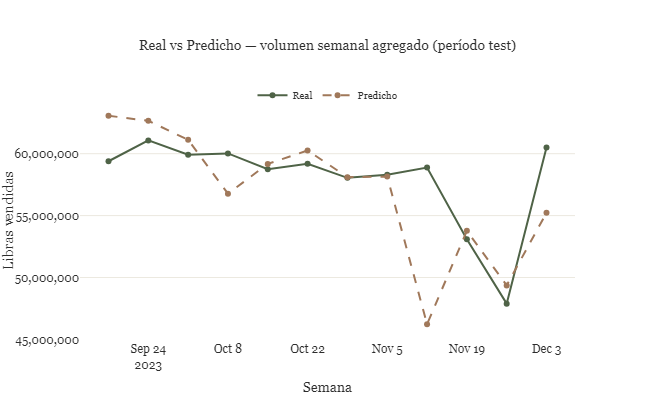

In [86]:
# ── GRÁFICO: Real vs Predicho ─────────────────────────────────────────────────

resultado = test[["Fecha", "Region_Geo", "Tipo", TARGET]].copy()
resultado["Predicho"] = y_pred

# Agregamos por fecha para ver tendencia nacional
comp = (
    resultado
    .groupby("Fecha")[["TotalVolume", "Predicho"]]
    .sum()
    .reset_index()
)

fig_eval = go.Figure()

fig_eval.add_trace(go.Scatter(
    x    = comp["Fecha"],
    y    = comp["TotalVolume"],
    name = "Real",
    mode = "lines+markers",
    line = dict(color=PALETA["musgo"], width=2),
    marker = dict(size=6),
))

fig_eval.add_trace(go.Scatter(
    x    = comp["Fecha"],
    y    = comp["Predicho"],
    name = "Predicho",
    mode = "lines+markers",
    line = dict(color=PALETA["tierra"], width=2, dash="dash"),
    marker = dict(size=6),
))

fig_eval.update_layout(
    title       = "Real vs Predicho — volumen semanal agregado (período test)",
    xaxis_title = "Semana",
    yaxis_title = "Libras vendidas",
    yaxis       = dict(tickformat=",.0f"),
    height      = 420,
    legend      = dict(orientation="h", y=1.08, x=0.5, xanchor="center"),
)

fig_eval.show()

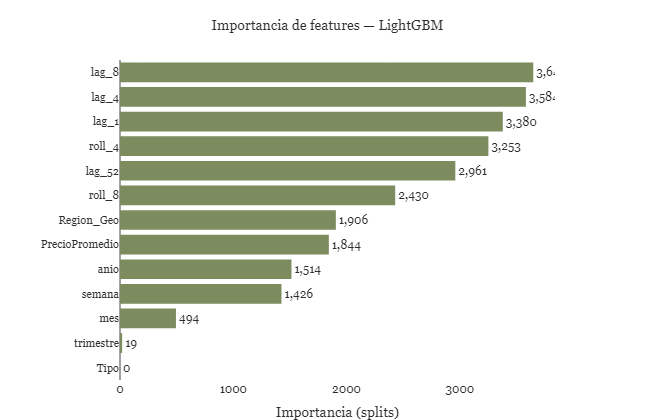

In [87]:
# ── GRÁFICO: Importancia de features ─────────────────────────────────────────

importancia = pd.DataFrame({
    "Feature":     FEATURES,
    "Importancia": modelo.feature_importances_,
}).sort_values("Importancia")

fig_imp = go.Figure()

fig_imp.add_trace(go.Bar(
    x            = importancia["Importancia"],
    y            = importancia["Feature"],
    orientation  = "h",
    marker_color = PALETA["oliva"],
    text         = importancia["Importancia"].apply(lambda x: f"{x:,.0f}"),
    textposition = "outside",
))

fig_imp.update_layout(
    title       = "Importancia de features — LightGBM",
    xaxis_title = "Importancia (splits)",
    yaxis_title = "",
    height      = 420,
    margin      = dict(l=120, r=100, t=60, b=40),
    yaxis       = dict(tickfont=dict(size=11)),
)

fig_imp.show()

## Conclusiones del modelo predictivo — LightGBM

### ¿Qué aprendió el modelo?
El mejor predictor de la demanda futura de paltas es la demanda pasada reciente.
Los lags (lag_1, lag_4, lag_8) y promedios móviles (roll_4, roll_8) dominan
la importancia de features, lo que confirma que el mercado de paltas tiene
inercia — lo que se vendió las últimas semanas es la mejor señal de lo que
se venderá la próxima.

### Métricas 
| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| MAE |  lbs | Error promedio absoluto |
| RMSE | lbs | Sensible a errores grandes puntuales |
| MAPE | | No confiable — regiones con volumen cercano a cero distorsionan |
| Error relativo |  | El modelo se equivoca x% del volumen típico |



### Limitaciones del modelo actual


- 23.9% de error relativo es el techo razonable para un modelo global sin datos externos. Para bajar más necesitarías variables que no están en el dataset — clima, promociones, eventos.eventos de demanda (Super Bowl, Cinco de Mayo)
  
### Próximos pasos para mejorar



In [88]:
# ── EVALUACIÓN POR REGIÓN ─────────────────────────────────────────────────────

resultado = test[["Fecha", "Region_Geo", "TotalVolume"]].copy()
resultado["Predicho"] = y_pred
resultado["error_abs"] = (resultado["TotalVolume"] - resultado["Predicho"]).abs()

eval_region = (
    resultado
    .groupby("Region_Geo")
    .agg(
        MAE          = ("error_abs",   "mean"),
        Volumen_medio = ("TotalVolume", "mean"),
    )
    .assign(Error_relativo = lambda df: df["MAE"] / df["Volumen_medio"] * 100)
    .sort_values("Error_relativo", ascending=False)
    .reset_index()
)

eval_region["MAE"]            = eval_region["MAE"].apply(lambda x: f"{x:,.0f}")
eval_region["Error_relativo"] = eval_region["Error_relativo"].apply(lambda x: f"{x:.1f}%")
eval_region["Volumen_medio"]  = eval_region["Volumen_medio"].apply(lambda x: f"{x:,.0f}")

display(eval_region)

,Region_Geo,MAE,Volumen_medio,Error_relativo
0,Northeast,"348,265","791,186",44.0%
1,GreatLakes,"324,609","785,132",41.3%
2,Midsouth,"313,272","848,104",36.9%
3,PeoriaSpringfield,"34,961","98,360",35.5%
4,NewOrleans,"84,921","261,418",32.5%
5,Providence,"24,464","76,054",32.2%
6,Toledo,"31,937","104,191",30.7%
7,Plains,"250,355","912,377",27.4%
8,Wichita,"20,679","89,207",23.2%
9,Southeast,"180,972","997,735",18.1%


In [89]:
print(resultado[resultado["Region_Geo"] == "Miami"].shape)
print(resultado[resultado["Region_Geo"] == "Miami"]["TotalVolume"].describe())

(0, 5)
count   0.00
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: TotalVolume, dtype: float64


In [90]:
print(predictivo_1[predictivo_1["Region_Geo"] == "Miami"]["Fecha"].describe())

count                              353
mean     2018-07-15 00:16:19.036827136
min                2015-03-01 00:00:00
25%                2016-11-06 00:00:00
50%                2018-07-15 00:00:00
75%                2020-03-22 00:00:00
max                2021-11-28 00:00:00
Name: Fecha, dtype: object


In [91]:
fecha_corte = predictivo_1["Fecha"].max() - pd.Timedelta(weeks=12)
print(f"Fecha de corte : {fecha_corte.date()}")
print(f"Miami max fecha: {predictivo_1[predictivo_1['Region_Geo'] == 'Miami']['Fecha'].max().date()}")

Fecha de corte : 2023-09-10
Miami max fecha: 2021-11-28


- **Miami excluida de la evaluación por región** — sus datos llegan hasta noviembre 2021, 
dos años antes del período de test (sep 2023). No es un error del modelo sino una limitación del dataset.